<a href="https://colab.research.google.com/github/DTeklehaymanot/wafer_defect_classification/blob/main/wafer_defect_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GPU-Accelerated Semiconductor Wafer Defect Classification

This project develops a PyTorch computer-vision model to classify semiconductor
wafer-map failure patterns. Model training and inference will be accelerated using
an NVIDIA GPU through CUDA and benchmarked against CPU execution.

Dataset: WM-811K Wafer Map Dataset from Kaggle

In [ ]:
import time
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
# Check whether PyTorch can access an NVIDIA GPU.
gpu_available = torch.cuda.is_available()

# Choose the GPU if available; otherwise choose the CPU.
device = torch.device("cuda" if gpu_available else "cpu")

print("PyTorch version:", torch.__version__)
print("CUDA available:", gpu_available)
print("Selected device:", device)

# Only ask for the GPU's name if a GPU is available.
if gpu_available:
    print("GPU name:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu130
CUDA available: True
Selected device: cuda
GPU name: Tesla T4


In [ ]:
from google.colab import drive
from pathlib import Path

# Connect Google Drive.
drive.mount("/content/drive")

# Match my existing folder names.
project_folder = Path("/content/drive/MyDrive/wafer_defect_project")

data_folder = project_folder / "Data"
checkpoint_folder = project_folder / "Checkpoints"
results_folder = project_folder / "Results"

# Check that Colab can find each folder.
for folder in [data_folder, checkpoint_folder, results_folder]:
    print(f"{folder.name}: {folder.is_dir()}")

Mounted at /content/drive
Data: True
Checkpoints: True
Results: True


In [ ]:
# Build the path to the dataset file.
dataset_path = data_folder / "LSWMD.pkl"

# Check whether the file is accessible.
print("Dataset path:", dataset_path)
print("File found:", dataset_path.is_file())

# Display its size if it exists.
if dataset_path.is_file():
    size_mb = dataset_path.stat().st_size / (1024 ** 2)
    print(f"File size: {size_mb:.1f} MB")

Dataset path: /content/drive/MyDrive/wafer_defect_project/Data/LSWMD.pkl
File found: True
File size: 1998.4 MB


In [ ]:
import pandas as pd

df = pd.read_pickle(dataset_path)

print("Dataset loaded successfully!")
print("Rows and columns:", df.shape)
print("Column names:", df.columns.tolist())

display(df.head(3))

Dataset loaded successfully!
Rows and columns: (811457, 6)
Column names: ['waferMap', 'dieSize', 'lotName', 'waferIndex', 'trianTestLabel', 'failureType']


,waferMap,dieSize,lotName,waferIndex,trianTestLabel,failureType
0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,1.0,[[Training]],[[none]]
1,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,2.0,[[Training]],[[none]]
2,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,3.0,[[Training]],[[none]]


Map shape: (45, 48)
Unique cell values: [0 1 2]
Stored label: [['none']]


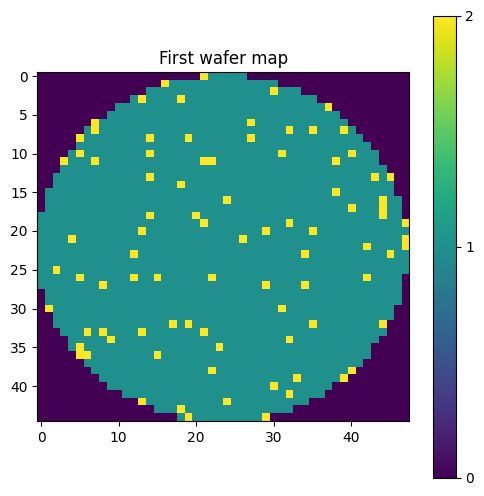

In [ ]:
# Select the first row of the table.
first_wafer = df.iloc[0]

# Retrieve its wafer-map array.
wafer_map = first_wafer["waferMap"]

print("Map shape:", wafer_map.shape)
print("Unique cell values:", np.unique(wafer_map))
print("Stored label:", first_wafer["failureType"])

# Display the numerical array as an image.
plt.figure(figsize=(6, 6))
plt.imshow(
    wafer_map,
    interpolation="nearest",
    vmin=0,
    vmax=2
)
plt.title("First wafer map")
plt.colorbar(ticks=[0, 1, 2])
plt.show()

In [ ]:
# Convert one stored label into a plain string.
def clean_label(stored_label):
    values = np.asarray(stored_label).flatten()

    if values.size == 0:
        return None

    return str(values[0])

# Create a new column while keeping the original.
df["label"] = df["failureType"].apply(clean_label)

# Compare the original and cleaned labels.
display(df[["failureType", "label"]].head(5))

# Count each category, including missing labels.
print(df["label"].value_counts(dropna=False))

,failureType,label
0,[[none]],none
1,[[none]],none
2,[[none]],none
3,[[none]],none
4,[[none]],none


label
None         638507
none         147431
Edge-Ring      9680
Edge-Loc       5189
Center         4294
Loc            3593
Scratch        1193
Random          866
Donut           555
Near-full       149
Name: count, dtype: int64


In [ ]:
# Select rows that have a known label.
labeled_df = df.loc[df["label"].notna()].copy()

print("Original number of wafers:", len(df))
print("Labeled wafers:", len(labeled_df))
print("Excluded unlabeled wafers:", len(df) - len(labeled_df))
print("Number of categories:", labeled_df["label"].nunique())

print("\nCategory counts:")
print(labeled_df["label"].value_counts())

Original number of wafers: 811457
Labeled wafers: 172950
Excluded unlabeled wafers: 638507
Number of categories: 9

Category counts:
label
none         147431
Edge-Ring      9680
Edge-Loc       5189
Center         4294
Loc            3593
Scratch        1193
Random          866
Donut           555
Near-full       149
Name: count, dtype: int64


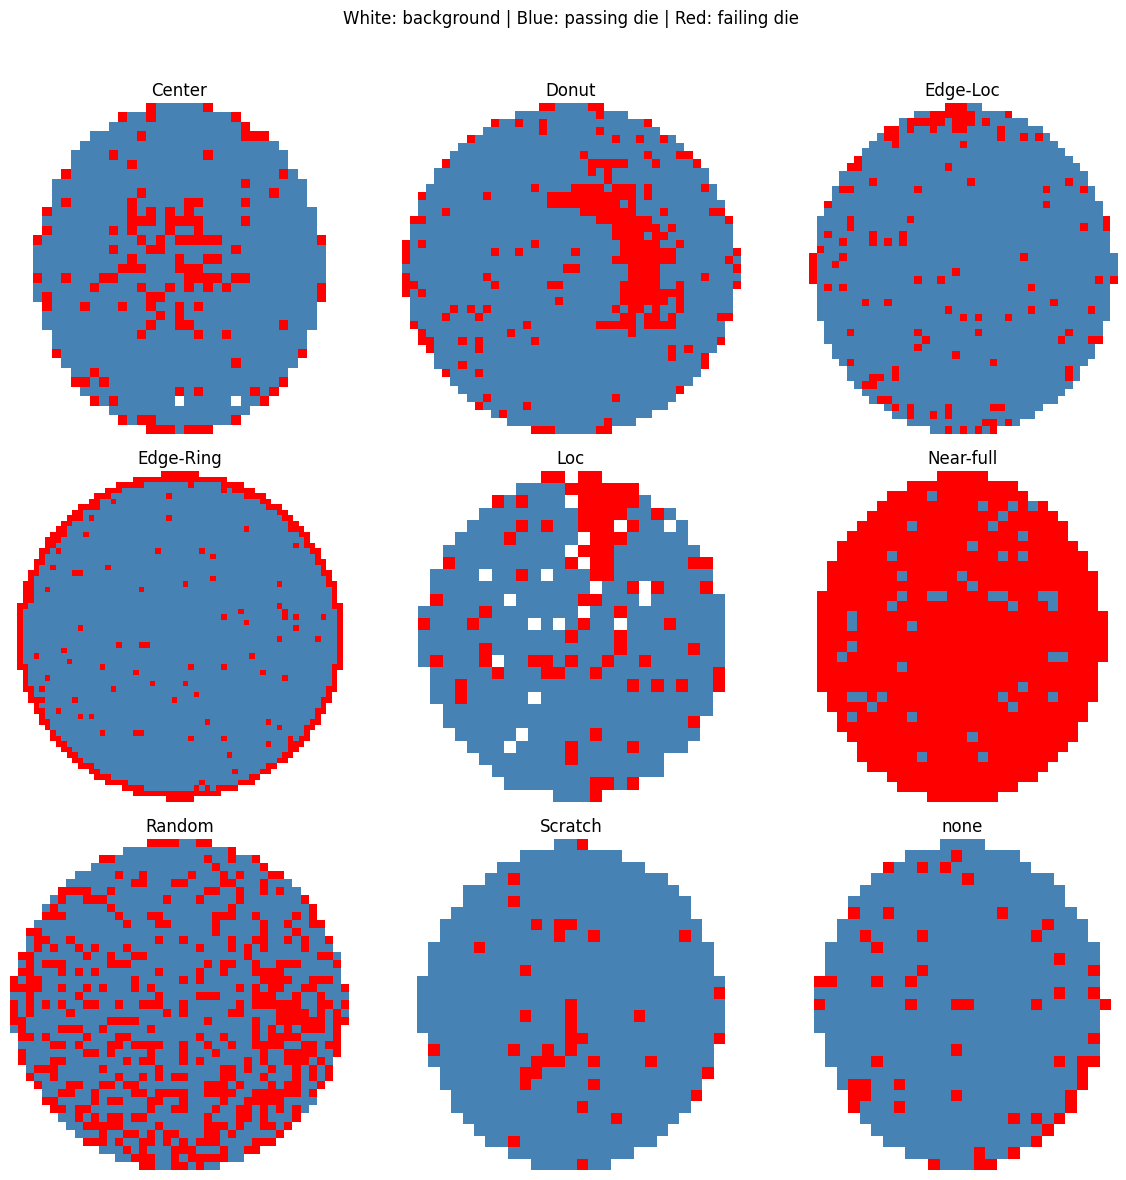

In [ ]:
from matplotlib.colors import ListedColormap

wafer_colors = ListedColormap(["white", "steelblue", "red"])

# Get the nine category names in alphabetical order.
class_names = sorted(labeled_df["label"].unique())

# Create a figure containing nine plots.
fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for ax, class_name in zip(axes.flat, class_names):
    # Select the rows belonging to this category.
    class_rows = labeled_df.loc[
        labeled_df["label"] == class_name
    ]

    # Pick one reproducible example.
    example = class_rows.sample(n=1, random_state=42).iloc[0]

    # Display its wafer map.
    ax.imshow(
        example["waferMap"],
        cmap=wafer_colors,
        vmin=0,
        vmax=2,
        interpolation="nearest"
    )
    ax.set_title(class_name)
    ax.axis("off")

fig.suptitle(
    "White: background | Blue: passing die | Red: failing die"
)
fig.tight_layout(rect=[0, 0, 1, 0.96])

# Save the figure to your existing Results folder.
fig.savefig(results_folder / "wafer_class_examples.png", dpi=150)

plt.show()

In [ ]:
# Check whether manufacturing-lot identifiers are available.
print("Labeled wafers:", len(labeled_df))
print("Unique lots:", labeled_df["lotName"].nunique())
print("Missing lot names:", labeled_df["lotName"].isna().sum())

# Count how many different lots contain each category.
lots_per_class = (
    labeled_df.groupby("label")["lotName"]
    .nunique()
    .sort_values()
)

print("\nNumber of lots containing each category:")
print(lots_per_class)

# Inspect the training/test assignments supplied with the dataset.
original_split = labeled_df["trianTestLabel"].apply(clean_label)

print("\nOriginal dataset assignments:")
print(original_split.value_counts(dropna=False))

Labeled wafers: 172950
Unique lots: 10762
Missing lot names: 0

Number of lots containing each category:
label
Near-full     137
Donut         233
Random        449
Scratch      1059
Edge-Ring    1075
Center       1648
Loc          2472
Edge-Loc     3211
none         6591
Name: lotName, dtype: int64

Original dataset assignments:
trianTestLabel
Test        118595
Training     54355
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import GroupShuffleSplit

# First: assign about 70% of lots to training.
first_split = GroupShuffleSplit(
    n_splits=1,
    test_size=0.30,
    random_state=42
)

train_positions, remaining_positions = next(
    first_split.split(
        labeled_df,
        groups=labeled_df["lotName"]
    )
)

train_df = labeled_df.iloc[train_positions].copy()
remaining_df = labeled_df.iloc[remaining_positions].copy()

# Second: divide the remaining lots equally between validation and test.
second_split = GroupShuffleSplit(
    n_splits=1,
    test_size=0.50,
    random_state=42
)

val_positions, test_positions = next(
    second_split.split(
        remaining_df,
        groups=remaining_df["lotName"]
    )
)

val_df = remaining_df.iloc[val_positions].copy()
test_df = remaining_df.iloc[test_positions].copy()

In [ ]:
# Show the number and percentage of wafers in each partition.
for name, partition in [
    ("Training", train_df),
    ("Validation", val_df),
    ("Test", test_df)
]:
    percentage = 100 * len(partition) / len(labeled_df)
    print(f"{name}: {len(partition):,} wafers ({percentage:.1f}%)")

# Compare category counts across the three partitions.
class_counts = pd.DataFrame({
    "Training": train_df["label"].value_counts(),
    "Validation": val_df["label"].value_counts(),
    "Test": test_df["label"].value_counts()
}).fillna(0).astype(int)

display(class_counts)

# Check that no manufacturing lot appears in two partitions.
train_lots = set(train_df["lotName"])
val_lots = set(val_df["lotName"])
test_lots = set(test_df["lotName"])

assert train_lots.isdisjoint(val_lots)
assert train_lots.isdisjoint(test_lots)
assert val_lots.isdisjoint(test_lots)

assert (class_counts > 0).all().all(), "A partition is missing a category."

print("Checks passed: no shared lots, and all categories are present.")

Training: 120,979 wafers (70.0%)
Validation: 26,116 wafers (15.1%)
Test: 25,855 wafers (14.9%)


,Training,Validation,Test
label,,,
none,103101,22264,22066
Edge-Ring,6871,1377,1432
Edge-Loc,3630,787,772
Center,3008,683,603
Loc,2411,606,576
Scratch,871,145,177
Random,614,121,131
Donut,366,106,83
Near-full,107,27,15


Checks passed: no shared lots, and all categories are present.


In [ ]:
import hashlib

# Create a fingerprint from a map's shape and cell values.
def map_fingerprint(wafer_map):
    array = np.asarray(wafer_map, dtype=np.uint8)

    shape_bytes = str(array.shape).encode("utf-8")
    map_bytes = array.tobytes()

    return hashlib.sha256(shape_bytes + map_bytes).hexdigest()

# Calculate one fingerprint per wafer map.
for partition in [train_df, val_df, test_df]:
    partition["map_hash"] = partition["waferMap"].apply(
        map_fingerprint
    )

# Collect the distinct fingerprints in each partition.
train_hashes = set(train_df["map_hash"])
val_hashes = set(val_df["map_hash"])
test_hashes = set(test_df["map_hash"])

print("Shared unique maps:")
print("Train / Validation:", len(train_hashes & val_hashes))
print("Train / Test:", len(train_hashes & test_hashes))
print("Validation / Test:", len(val_hashes & test_hashes))

Shared unique maps:
Train / Validation: 682
Train / Test: 705
Validation / Test: 163


In [ ]:
# Combine only the metadata needed for this check.
# We do not copy the large wafer-map arrays.
map_records = pd.concat([
    train_df[["map_hash", "label"]].assign(split="Training"),
    val_df[["map_hash", "label"]].assign(split="Validation"),
    test_df[["map_hash", "label"]].assign(split="Test")
])

# Collect fingerprints shared between any two partitions.
shared_hashes = (
    (train_hashes & val_hashes)
    | (train_hashes & test_hashes)
    | (val_hashes & test_hashes)
)

# Select every record whose map appears across partitions.
shared_records = map_records.loc[
    map_records["map_hash"].isin(shared_hashes)
]

print("Distinct maps shared across partitions:", len(shared_hashes))

print("\nAffected wafer records by category and partition:")
display(pd.crosstab(
    shared_records["label"],
    shared_records["split"]
))

# Check whether identical maps have different category labels.
labels_per_map = shared_records.groupby("map_hash")["label"].nunique()

print(
    "\nShared maps with conflicting labels:",
    (labels_per_map > 1).sum()
)

Distinct maps shared across partitions: 1550

Affected wafer records by category and partition:


split,Test,Training,Validation
label,,,
Center,2,4,2
Edge-Loc,10,13,10
Edge-Ring,2,4,4
Loc,5,7,3
Near-full,3,5,3
Random,4,6,2
Scratch,3,4,1
none,840,1345,820



Shared maps with conflicting labels: 4


In [ ]:
# Check for conflicting labels across ALL records,
# including duplicates within a single partition.
label_counts = map_records.groupby("map_hash")["label"].nunique()
conflicting_hashes = set(label_counts[label_counts > 1].index)

print("Maps with conflicting labels:", len(conflicting_hashes))

# Exclude ambiguous maps from every partition.
train_clean = train_df.loc[
    ~train_df["map_hash"].isin(conflicting_hashes)
].copy()

val_clean = val_df.loc[
    ~val_df["map_hash"].isin(conflicting_hashes)
].copy()

test_clean = test_df.loc[
    ~test_df["map_hash"].isin(conflicting_hashes)
].copy()

# Test takes priority: remove its matching maps from validation.
test_map_hashes = set(test_clean["map_hash"])

val_clean = val_clean.loc[
    ~val_clean["map_hash"].isin(test_map_hashes)
].copy()

# Remove maps from training if they appear in either held-out set.
held_out_hashes = test_map_hashes | set(val_clean["map_hash"])

train_clean = train_clean.loc[
    ~train_clean["map_hash"].isin(held_out_hashes)
].copy()

Maps with conflicting labels: 14


In [ ]:
# Report how many rows were excluded.
for name, original, cleaned in [
    ("Training", train_df, train_clean),
    ("Validation", val_df, val_clean),
    ("Test", test_df, test_clean)
]:
    print(
        f"{name}: {len(cleaned):,} remaining; "
        f"{len(original) - len(cleaned):,} excluded"
    )

# Verify both map separation and lot separation.
for column in ["map_hash", "lotName"]:
    train_values = set(train_clean[column])
    val_values = set(val_clean[column])
    test_values = set(test_clean[column])

    assert train_values.isdisjoint(val_values)
    assert train_values.isdisjoint(test_values)
    assert val_values.isdisjoint(test_values)

# Check that all nine categories remain in each partition.
clean_counts = pd.DataFrame({
    "Training": train_clean["label"].value_counts(),
    "Validation": val_clean["label"].value_counts(),
    "Test": test_clean["label"].value_counts()
}).reindex(class_names).fillna(0).astype(int)

display(clean_counts)

assert (clean_counts > 0).all().all(), "A category is missing."

print("Checks passed: no shared maps or lots; all categories remain.")

Training: 119,573 remaining; 1,406 excluded
Validation: 25,949 remaining; 167 excluded
Test: 25,853 remaining; 2 excluded


,Training,Validation,Test
label,,,
Center,3003,683,602
Donut,366,106,83
Edge-Loc,3610,782,772
Edge-Ring,6865,1376,1432
Loc,2402,606,575
Near-full,102,26,15
Random,608,121,131
Scratch,867,145,177
none,101750,22104,22066


Checks passed: no shared maps or lots; all categories remain.


In [ ]:
class_names = sorted(train_clean["label"].unique())

class_to_idx = {}

for number, class_name in enumerate(class_names):
    class_to_idx[class_name] = number

print(class_to_idx)

{'Center': 0, 'Donut': 1, 'Edge-Loc': 2, 'Edge-Ring': 3, 'Loc': 4, 'Near-full': 5, 'Random': 6, 'Scratch': 7, 'none': 8}


In [ ]:
import json

# Save the category-to-number mapping.
mapping_path = data_folder / "class_to_idx.json"

with open(mapping_path, "w") as file:
    json.dump(class_to_idx, file, indent=2)

# Build a small table identifying the retained wafer records.
manifest_parts = []

for split_name, partition in [
    ("train", train_clean),
    ("validation", val_clean),
    ("test", test_clean)
]:
    records = partition[
        ["lotName", "waferIndex", "label", "map_hash"]
    ].copy()

    records["source_row"] = partition.index
    records["split"] = split_name
    records["class_id"] = records["label"].map(class_to_idx)

    manifest_parts.append(records)

split_manifest = pd.concat(manifest_parts, ignore_index=True)

# Each original wafer record should appear only once.
assert split_manifest["source_row"].is_unique
assert split_manifest["class_id"].notna().all()

manifest_path = data_folder / "split_manifest.csv"
split_manifest.to_csv(manifest_path, index=False)

print("Saved:", mapping_path)
print("Saved:", manifest_path)

Saved: /content/drive/MyDrive/wafer_defect_project/Data/class_to_idx.json
Saved: /content/drive/MyDrive/wafer_defect_project/Data/split_manifest.csv


In [ ]:
saved_manifest = pd.read_csv(
    manifest_path,
    keep_default_na=False
)

with open(mapping_path, "r") as file:
    saved_mapping = json.load(file)

assert len(saved_manifest) == len(split_manifest)
assert saved_manifest["source_row"].is_unique
assert saved_mapping == class_to_idx

print(saved_manifest["split"].value_counts())
print("Saved files verified.")

split
train         119573
validation     25949
test           25853
Name: count, dtype: int64
Saved files verified.


In [5]:
IMAGE_SIZE = 128


# Define resizing and normalization.
image_transform = transforms.Compose([
    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE),
        interpolation=transforms.InterpolationMode.NEAREST
    ),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

def preprocess_wafer(wafer_map):
    # Find the map's dimensions.
    height, width = wafer_map.shape
    side = max(height, width)

    # Work out how much background to add on each side.
    top = (side - height) // 2
    bottom = side - height - top
    left = (side - width) // 2
    right = side - width - left

    # Pad with zeros, which represent background.
    square_map = np.pad(
        wafer_map,
        ((top, bottom), (left, right)),
        mode="constant",
        constant_values=0
    )

    # Convert values 0, 1, 2 into 0.0, 0.5, 1.0.
    image = torch.tensor(square_map, dtype=torch.float32) / 2.0

    # Add a channel dimension and repeat it three times.
    image = image.unsqueeze(0).repeat(3, 1, 1)

    # Resize and normalize.
    return image_transform(image)

In [ ]:
# Select the first Scratch wafer from the training data.
example_row = train_clean.loc[
    train_clean["label"] == "Scratch"
].iloc[0]

# Extract its map and apply preprocessing.
original_map = example_row["waferMap"]
image_tensor = preprocess_wafer(original_map)

# Display the dimensions and data type.
print("Original shape:", original_map.shape)
print("Processed shape:", image_tensor.shape)
print("Data type:", image_tensor.dtype)

# Check the expected dimensions and numerical validity.
assert image_tensor.shape == (3, 128, 128)
assert torch.isfinite(image_tensor).all()

Original shape: (53, 58)
Processed shape: torch.Size([3, 128, 128])
Data type: torch.float32


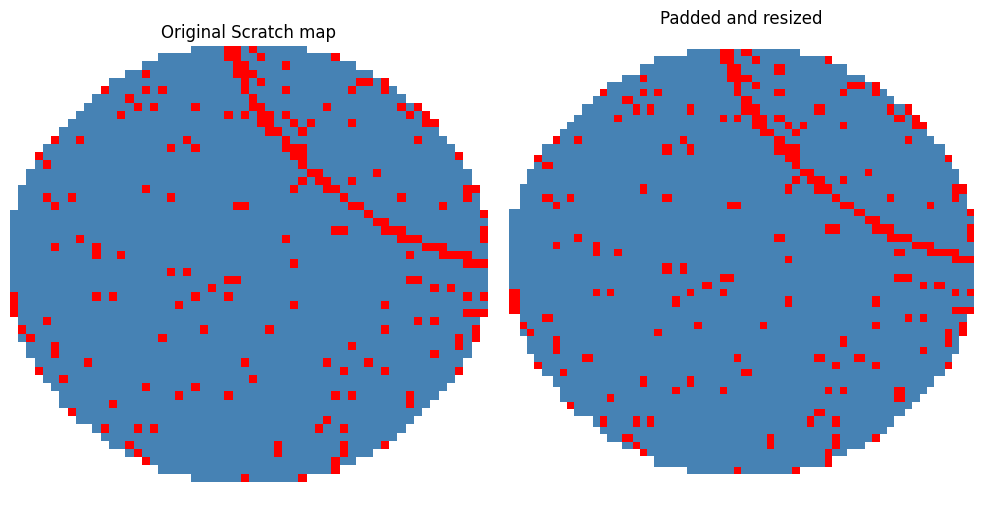

In [ ]:
# Undo normalization on the first channel for display.
display_map = (image_tensor[0] * 0.229 + 0.485) * 2.0

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(
    original_map, cmap=wafer_colors,
    vmin=0, vmax=2, interpolation="nearest"
)
axes[0].set_title("Original Scratch map")

axes[1].imshow(
    display_map.numpy(), cmap=wafer_colors,
    vmin=0, vmax=2, interpolation="nearest"
)
axes[1].set_title("Padded and resized")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

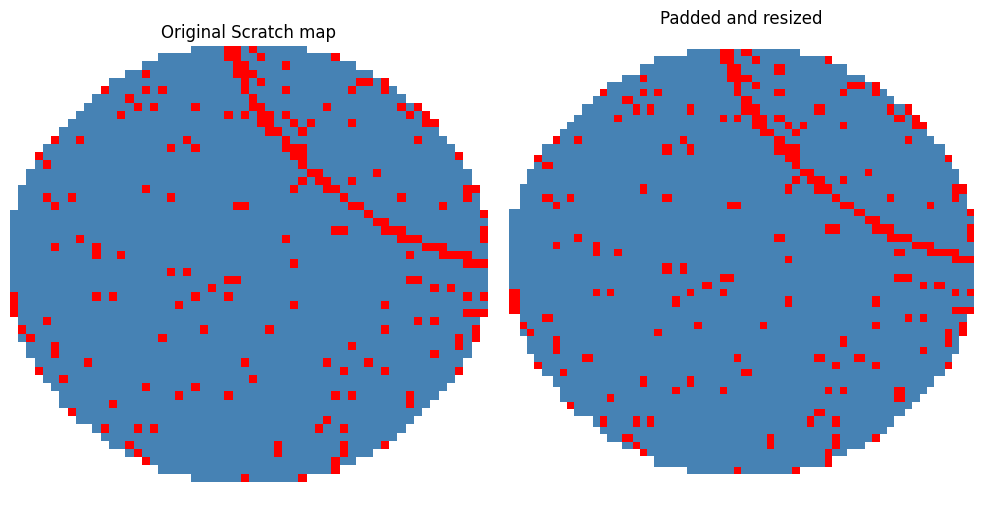

In [ ]:
# Undo normalization on the first channel for display.
display_map = (image_tensor[0] * 0.229 + 0.485) * 2.0

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(
    original_map, cmap=wafer_colors,
    vmin=0, vmax=2, interpolation="nearest"
)
axes[0].set_title("Original Scratch map")

axes[1].imshow(
    display_map.numpy(), cmap=wafer_colors,
    vmin=0, vmax=2, interpolation="nearest"
)
axes[1].set_title("Padded and resized")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()


In [8]:
from torch.utils.data import Dataset

class WaferDataset(Dataset):
    def __init__(self, dataframe, class_to_idx):
        self.records = dataframe[["waferMap", "label"]].reset_index(drop=True)
        self.class_to_idx = class_to_idx

    def __len__(self):
        return len(self.records)

    def __getitem__(self, index):
        row = self.records.iloc[index]

        image = preprocess_wafer(row["waferMap"])

        label_id = self.class_to_idx[row["label"]]
        label = torch.tensor(label_id, dtype=torch.long)

        return image, label

In [9]:
train_dataset = WaferDataset(train_clean, class_to_idx)
val_dataset = WaferDataset(val_clean, class_to_idx)
test_dataset = WaferDataset(test_clean, class_to_idx)

print("Training examples:", len(train_dataset))
print("Validation examples:", len(val_dataset))
print("Test examples:", len(test_dataset))

Training examples: 119573
Validation examples: 25949
Test examples: 25853


In [10]:
image, label = train_dataset[0]

print("Image shape:", image.shape)
print("Label ID:", label.item())
print("Original label:", train_clean.iloc[0]["label"])

assert image.shape == (3, 128, 128)
assert torch.isfinite(image).all()
assert label.dtype == torch.long
assert label.item() == class_to_idx[train_clean.iloc[0]["label"]]

Image shape: torch.Size([3, 128, 128])
Label ID: 8
Original label: none


In [11]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

In [ ]:
images, labels = next(iter(train_loader))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("Image data type:", images.dtype)
print("Label data type:", labels.dtype)

Images shape: torch.Size([32, 3, 128, 128])
Labels shape: torch.Size([32])
Image data type: torch.float32
Label data type: torch.int64


In [12]:
assert images.shape == (BATCH_SIZE, 3, IMAGE_SIZE, IMAGE_SIZE)
assert labels.shape == (BATCH_SIZE,)

assert torch.isfinite(images).all()
assert labels.dtype == torch.long

assert labels.min().item() >= 0
assert labels.max().item() < len(class_to_idx)

print("Batch checks passed.")

NameError: name 'images' is not defined

In [ ]:
from google.colab import drive
from pathlib import Path
import json

import numpy as np
import pandas as pd
import torch
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader

drive.mount("/content/drive")

project_folder = Path("/content/drive/MyDrive/wafer_defect_project")
data_folder = project_folder / "Data"
checkpoint_folder = project_folder / "Checkpoints"
results_folder = project_folder / "Results"

required_files = [
    "LSWMD.pkl",
    "split_manifest.csv",
    "class_to_idx.json",
]

for filename in required_files:
    path = data_folder / filename
    print(filename, "exists:", path.exists())
    assert path.exists(), f"Missing file: {filename}"

Mounted at /content/drive
LSWMD.pkl exists: True
split_manifest.csv exists: True
class_to_idx.json exists: True


In [ ]:
df = pd.read_pickle(data_folder / "LSWMD.pkl")

split_manifest = pd.read_csv(
    data_folder / "split_manifest.csv",
    keep_default_na=False
)

with open(data_folder / "class_to_idx.json", "r") as file:
    class_to_idx = json.load(file)

print("Original dataset rows:", len(df))
print("Saved split rows:", len(split_manifest))

Original dataset rows: 811457
Saved split rows: 171375


In [ ]:
def restore_split(split_name):
    records = split_manifest.loc[
        split_manifest["split"] == split_name
    ]

    restored = df.loc[records["source_row"]].copy()

    restored["label"] = records["label"].to_numpy()
    restored["map_hash"] = records["map_hash"].to_numpy()

    return restored


assert df.index.is_unique
assert split_manifest["source_row"].is_unique
assert split_manifest["source_row"].isin(df.index).all()

train_clean = restore_split("train")
val_clean = restore_split("validation")
test_clean = restore_split("test")

class_names = sorted(class_to_idx)

print("Training:", len(train_clean))
print("Validation:", len(val_clean))
print("Test:", len(test_clean))

Training: 119573
Validation: 25949
Test: 25853


In [3]:
from torch import nn
from torchvision import models

torch.manual_seed(42)

device = torch.device("cuda")

weights = models.ResNet18_Weights.IMAGENET1K_V1
model = models.resnet18(weights=weights)

print("Original classifier:", model.fc)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 186MB/s]


Original classifier: Linear(in_features=512, out_features=1000, bias=True)


In [ ]:
# Freeze the existing parameters
for parameter in model.parameters():
    parameter.requires_grad = False

# Replace the original classifier
num_features = model.fc.in_features
num_classes = len(class_to_idx)

model.fc = nn.Linear(num_features, num_classes)
model = model.to(device)

print("New classifier:", model.fc)

trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print("Trainable parameters:", trainable_parameters)

New classifier: Linear(in_features=512, out_features=9, bias=True)
Trainable parameters: 4617


In [ ]:
# Get one batch, then select two images
images, labels = next(iter(train_loader))
sample_images = images[:2].to(device)

# Set the model to evaluation mode
model.eval()

# Calculate outputs without tracking gradients
with torch.no_grad():
    outputs = model(sample_images)

print("Input shape:", sample_images.shape)
print("Output shape:", outputs.shape)

assert outputs.shape == (2, num_classes)
assert torch.isfinite(outputs).all()

print("Model check passed.")

Input shape: torch.Size([2, 3, 128, 128])
Output shape: torch.Size([2, 9])
Model check passed.


In [13]:
# Put class names in the same order as their numeric IDs
class_order = sorted(class_to_idx, key=class_to_idx.get)

# Count examples using only the training set
class_counts = (
    train_clean["label"]
    .value_counts()
    .reindex(class_order)
)

assert class_counts.notna().all()
assert (class_counts > 0).all()

# Give less frequent classes larger weights
class_weights = len(train_clean) / (len(class_order) * class_counts)

print(pd.DataFrame({
    "Training examples": class_counts,
    "Loss weight": class_weights
}))

           Training examples  Loss weight
label                                    
Center                  3003     4.424205
Donut                    366    36.300243
Edge-Loc                3610     3.680302
Edge-Ring               6865     1.935308
Loc                     2402     5.531178
Near-full                102   130.253813
Random                   608    21.851791
Scratch                  867    15.323978
none                  101750     0.130574


In [29]:
weight_tensor = torch.tensor(
    class_weights.to_numpy(),
    dtype=torch.float32,
    device=device
)

criterion = nn.CrossEntropyLoss(weight=weight_tensor)

In [30]:
optimizer = torch.optim.Adam(
    model.fc.parameters(),
    lr=0.001
)

In [31]:
images, labels = next(iter(train_loader))

sample_images = images[:2].to(device)
sample_labels = labels[:2].to(device)

model.eval()

with torch.no_grad():
    outputs = model(sample_images)
    loss = criterion(outputs, sample_labels)

assert torch.isfinite(loss).item()

print("Sample loss:", loss.item())

Sample loss: 2.4032955169677734


In [32]:
# Keep the frozen backbone's BatchNorm statistics fixed
model.eval()
model.fc.train()

# Save a copy so we can check whether weights change
weights_before = model.fc.weight.detach().clone()

# Clear gradients left over from any previous step
optimizer.zero_grad()

# Forward pass: calculate scores and loss
outputs = model(sample_images)
loss = criterion(outputs, sample_labels)

assert torch.isfinite(loss).item()

# Backward pass: calculate gradients
loss.backward()

# Update the classifier's parameters
optimizer.step()

print("Loss before update:", loss.item())

Loss before update: 2.4032955169677734


In [33]:
model.eval()

with torch.no_grad():
    outputs_after = model(sample_images)
    loss_after = criterion(outputs_after, sample_labels)

    largest_change = (
        model.fc.weight - weights_before
    ).abs().max().item()

print("Loss after update:", loss_after.item())
print("Largest classifier weight change:", largest_change)

assert largest_change > 0
assert torch.isfinite(loss_after).item()

Loss after update: 1.5180922746658325
Largest classifier weight change: 0.0010000001639127731


In [34]:
def train_classifier(
    model, loader, criterion, optimizer, device,
    max_batches=None
):
    # Keep the backbone fixed while training the classifier
    model.eval()
    model.fc.train()

    total_weighted_loss = 0.0
    total_weight = 0.0
    total_correct = 0
    total_examples = 0

    for batch_number, (images, labels) in enumerate(loader, start=1):
        images = images.to(device)
        labels = labels.to(device)

        # One training step
        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        assert torch.isfinite(loss).item(), "Loss is not finite"

        loss.backward()
        optimizer.step()

        # Accumulate the weighted loss correctly
        batch_weight = criterion.weight[labels].sum().item()
        total_weighted_loss += loss.item() * batch_weight
        total_weight += batch_weight

        # Count correct predictions
        predictions = outputs.argmax(dim=1)
        total_correct += (predictions == labels).sum().item()
        total_examples += labels.size(0)

        # Display progress during our short check
        if max_batches is not None:
            print(f"Batch {batch_number}: loss = {loss.item():.4f}")

        # Stop early when a batch limit is supplied
        if max_batches is not None and batch_number >= max_batches:
            break

    return {
        "loss": total_weighted_loss / total_weight,
        "accuracy": total_correct / total_examples,
        "examples": total_examples
    }

In [35]:
train_results = train_classifier(
    model=model,
    loader=train_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    max_batches=3
)

print("Examples processed:", train_results["examples"])
print("Weighted training loss:", train_results["loss"])
print(f"Training accuracy: {train_results['accuracy']:.2%}")

Batch 1: loss = 2.9310
Batch 2: loss = 2.2338
Batch 3: loss = 2.2471
Examples processed: 96
Weighted training loss: 2.7185486788110014
Training accuracy: 76.04%


In [36]:
from sklearn.metrics import accuracy_score, f1_score

def validate_classifier(
    model, loader, criterion, device,
    max_batches=None
):
    model.eval()

    total_weighted_loss = 0.0
    total_weight = 0.0

    all_labels = []
    all_predictions = []

    with torch.no_grad():
        for batch_number, (images, labels) in enumerate(loader, start=1):
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            assert torch.isfinite(loss).item(), "Loss is not finite"

            batch_weight = criterion.weight[labels].sum().item()
            total_weighted_loss += loss.item() * batch_weight
            total_weight += batch_weight

            predictions = outputs.argmax(dim=1)

            all_labels.extend(labels.cpu().tolist())
            all_predictions.extend(predictions.cpu().tolist())

            if max_batches is not None and batch_number >= max_batches:
                break

    return {
        "loss": total_weighted_loss / total_weight,
        "accuracy": accuracy_score(all_labels, all_predictions),
        "macro_f1": f1_score(
            all_labels,
            all_predictions,
            labels=list(range(model.fc.out_features)),
            average="macro",
            zero_division=0
        ),
        "examples": len(all_labels),
        "classes_present": len(set(all_labels))
    }

In [37]:
val_results = validate_classifier(
    model=model,
    loader=val_loader,
    criterion=criterion,
    device=device,
    max_batches=3
)

print("Validation examples checked:", val_results["examples"])
print("Classes present:", val_results["classes_present"])
print("Weighted validation loss:", val_results["loss"])
print(f"Validation accuracy: {val_results['accuracy']:.2%}")
print(f"Validation macro F1: {val_results['macro_f1']:.4f}")

Validation examples checked: 96
Classes present: 4
Weighted validation loss: 1.592777625725702
Validation accuracy: 96.88%
Validation macro F1: 0.1093


In [38]:
val_results = validate_classifier(
    model=model,
    loader=val_loader,
    criterion=criterion,
    device=device,
    max_batches=3
)

print("Validation examples checked:", val_results["examples"])
print("Classes present:", val_results["classes_present"])
print("Weighted validation loss:", val_results["loss"])
print(f"Validation accuracy: {val_results['accuracy']:.2%}")
print(f"Validation macro F1: {val_results['macro_f1']:.4f}")

Validation examples checked: 96
Classes present: 4
Weighted validation loss: 1.592777625725702
Validation accuracy: 96.88%
Validation macro F1: 0.1093


In [39]:
checkpoint_folder.mkdir(parents=True, exist_ok=True)

checkpoint_path = checkpoint_folder / "debug_checkpoint.pth"

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "class_to_idx": class_to_idx,
        "class_weights": criterion.weight.detach().cpu(),
        "image_size": IMAGE_SIZE,
        "architecture": "resnet18",
        "stage": "classifier_debug",
        "completed_epochs": 0,
    },
    checkpoint_path
)

print("Checkpoint saved:", checkpoint_path)

Checkpoint saved: /content/drive/MyDrive/wafer_defect_project/Checkpoints/debug_checkpoint.pth


In [41]:
saved_checkpoint = torch.load(
    checkpoint_path,
    map_location="cpu",
    weights_only=True
)

assert saved_checkpoint["class_to_idx"] == class_to_idx

assert torch.equal(
    saved_checkpoint["model_state_dict"]["fc.weight"],
    model.fc.weight.detach().cpu()
)

print("Checkpoint readable; classifier weights match.")

del saved_checkpoint

Checkpoint readable; classifier weights match.


In [42]:
# Choose the most common class using training data only
majority_class = train_clean["label"].value_counts().idxmax()
majority_id = class_to_idx[majority_class]

# Get the correct labels for the entire validation set
val_labels = val_clean["label"].map(class_to_idx).to_numpy()

# Predict the majority class for every validation example
baseline_predictions = np.full(len(val_labels), majority_id)

baseline_accuracy = accuracy_score(
    val_labels, baseline_predictions
)

baseline_macro_f1 = f1_score(
    val_labels,
    baseline_predictions,
    labels=list(range(len(class_to_idx))),
    average="macro",
    zero_division=0
)

print("Always predict:", majority_class)
print("Validation examples:", len(val_labels))
print(f"Baseline accuracy: {baseline_accuracy:.2%}")
print(f"Baseline macro F1: {baseline_macro_f1:.4f}")

Always predict: none
Validation examples: 25949
Baseline accuracy: 85.18%
Baseline macro F1: 0.1022


In [43]:
SEED = 42
LEARNING_RATE = 0.001

torch.manual_seed(SEED)
np.random.seed(SEED)

# Reload the pretrained model
model = models.resnet18(
    weights=models.ResNet18_Weights.IMAGENET1K_V1
)

# Freeze its existing parameters
for parameter in model.parameters():
    parameter.requires_grad = False

# Create a fresh classifier
model.fc = nn.Linear(
    model.fc.in_features,
    len(class_to_idx)
)

model = model.to(device)
model.eval()

# Start a fresh optimizer for this new model
optimizer = torch.optim.Adam(
    model.fc.parameters(),
    lr=LEARNING_RATE
)

# Keep our training-derived class weights
criterion = nn.CrossEntropyLoss(
    weight=weight_tensor.to(device)
)

# Give training-data shuffling its own random generator
train_generator = torch.Generator()
train_generator.manual_seed(SEED)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    generator=train_generator
)

print("Fresh model and training loader ready on:", device)

Fresh model and training loader ready on: cpu


In [44]:
required = [
    "train_clean",
    "val_clean",
    "train_loader",
    "val_loader",
    "model",
    "criterion",
    "optimizer",
    "train_classifier",
    "validate_classifier",
    "train_generator",
]

for name in required:
    print(name, "available:", name in globals())

train_clean available: True
val_clean available: True
train_loader available: True
val_loader available: True
model available: True
criterion available: True
optimizer available: True
train_classifier available: True
validate_classifier available: True
train_generator available: True


In [4]:
from google.colab import drive
from pathlib import Path
import json

import numpy as np
import pandas as pd
import torch
from torch import nn
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, f1_score

drive.mount("/content/drive")

project_folder = Path("/content/drive/MyDrive/wafer_defect_project")
data_folder = project_folder / "Data"
checkpoint_folder = project_folder / "Checkpoints"
results_folder = project_folder / "Results"

# Load saved data and metadata
df = pd.read_pickle(data_folder / "LSWMD.pkl")

split_manifest = pd.read_csv(
    data_folder / "split_manifest.csv",
    keep_default_na=False
)

with open(data_folder / "class_to_idx.json", "r") as file:
    class_to_idx = json.load(file)

# Rebuild the exact splits saved earlier
def restore_split(split_name):
    records = split_manifest.loc[
        split_manifest["split"] == split_name
    ]

    restored = df.loc[records["source_row"]].copy()
    restored["label"] = records["label"].to_numpy()
    restored["map_hash"] = records["map_hash"].to_numpy()

    return restored

assert df.index.is_unique
assert split_manifest["source_row"].is_unique
assert split_manifest["source_row"].isin(df.index).all()

train_clean = restore_split("train")
val_clean = restore_split("validation")
test_clean = restore_split("test")

class_names = sorted(class_to_idx)
device = torch.device("cpu")

print("Training:", len(train_clean))
print("Validation:", len(val_clean))
print("Test:", len(test_clean))

Mounted at /content/drive
Training: 119573
Validation: 25949
Test: 25853


In [55]:
from datetime import datetime

def fit_classifier(
    epochs,
    stage="classifier_training",
    parent_checkpoint=None
):
    run_name = (
        f"{stage}_"
        + datetime.now().strftime("%Y%m%d_%H%M%S_%f")
    )
    run_folder = checkpoint_folder / run_name
    run_folder.mkdir(parents=True, exist_ok=False)

    history = []
    best_macro_f1 = -1.0

    print("Checkpoints will be saved in:", run_folder)

    for epoch in range(1, epochs + 1):
        print(f"\nEpoch {epoch}/{epochs}: training...", flush=True)

        train_metrics = train_classifier(
            model=model,
            loader=train_loader,
            criterion=criterion,
            optimizer=optimizer,
            device=device,
            max_batches=None
        )

        print("Checking the full validation set...", flush=True)

        val_metrics = validate_classifier(
            model=model,
            loader=val_loader,
            criterion=criterion,
            device=device,
            max_batches=None
        )

        record = {
            "epoch": epoch,
            "train_loss": train_metrics["loss"],
            "train_accuracy": train_metrics["accuracy"],
            "val_loss": val_metrics["loss"],
            "val_accuracy": val_metrics["accuracy"],
            "val_macro_f1": val_metrics["macro_f1"],
        }
        history.append(record)

        improved = val_metrics["macro_f1"] > best_macro_f1

        if improved:
            best_macro_f1 = val_metrics["macro_f1"]

        checkpoint = {
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "class_to_idx": class_to_idx,
            "class_weights": criterion.weight.detach().cpu(),
            "image_size": IMAGE_SIZE,
            "architecture": "resnet18",
            "stage": stage,
            "parent_checkpoint": parent_checkpoint,
            "trainable_parameter_names": [
                name
                for name, parameter in model.named_parameters()
                if parameter.requires_grad
            ],
            "completed_epochs": epoch,
            "best_macro_f1": best_macro_f1,
            "history": history,
            "seed": SEED,
            "batch_size": BATCH_SIZE,
            "torch_rng_state": torch.get_rng_state(),
            "train_generator_state": train_generator.get_state(),
        }

        torch.save(checkpoint, run_folder / "latest.pth")

        if improved:
            torch.save(checkpoint, run_folder / "best.pth")

        pd.DataFrame(history).to_csv(
            run_folder / "history.csv",
            index=False
        )

        print(
            f"Training loss: {train_metrics['loss']:.4f} | "
            f"Validation loss: {val_metrics['loss']:.4f} | "
            f"Validation macro F1: {val_metrics['macro_f1']:.4f}"
        )
        print("Checkpoint saved.", flush=True)

    return history, run_folder

In [47]:
import torch

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
GPU: Tesla T4


In [49]:
device = torch.device("cuda")

model = model.to(device)
criterion = criterion.to(device)

# Create the optimizer after moving the model
# This resets Adam's history; full training has not started yet.
optimizer = torch.optim.Adam(
    model.fc.parameters(),
    lr=LEARNING_RATE
)

print("Model device:", next(model.parameters()).device)
print("Loss weights device:", criterion.weight.device)

assert next(model.parameters()).is_cuda
assert criterion.weight.is_cuda

Model device: cuda:0
Loss weights device: cuda:0


In [50]:
# Will run after preparing the GPU runtime
history, run_folder = fit_classifier(epochs=1)

Checkpoints will be saved in: /content/drive/MyDrive/wafer_defect_project/Checkpoints/head_20261007_001510_641120

Epoch 1/1: training...
Checking the full validation set...
Training loss: 1.1283 | Validation loss: 1.0724 | Validation macro F1: 0.5451
Checkpoint saved.


In [51]:
from sklearn.metrics import classification_report

model.eval()

val_true = []
val_pred = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)

        outputs = model(images)
        predictions = outputs.argmax(dim=1)

        val_true.extend(labels.cpu().tolist())
        val_pred.extend(predictions.cpu().tolist())

class_order = sorted(class_to_idx, key=class_to_idx.get)

print(classification_report(
    val_true,
    val_pred,
    labels=list(range(len(class_order))),
    target_names=class_order,
    digits=4,
    zero_division=0
))

              precision    recall  f1-score   support

      Center     0.3005    0.7511    0.4293       683
       Donut     0.5224    0.6604    0.5833       106
    Edge-Loc     0.2159    0.2916    0.2481       782
   Edge-Ring     0.7448    0.9608    0.8391      1376
         Loc     0.1032    0.3680    0.1612       606
   Near-full     0.8571    0.9231    0.8889        26
      Random     0.8319    0.8182    0.8250       121
     Scratch     0.3000    0.0207    0.0387       145
        none     0.9661    0.8287    0.8921     22104

    accuracy                         0.8015     25949
   macro avg     0.5380    0.6247    0.5451     25949
weighted avg     0.8878    0.8015    0.8343     25949



In [52]:
head_checkpoint_path = run_folder / "best.pth"

head_checkpoint = torch.load(
    head_checkpoint_path,
    map_location="cpu",
    weights_only=True
)

model.load_state_dict(head_checkpoint["model_state_dict"])

head_macro_f1 = head_checkpoint["best_macro_f1"]

print("Starting checkpoint:", head_checkpoint_path)
print("Previous validation macro F1:", head_macro_f1)

del head_checkpoint

Starting checkpoint: /content/drive/MyDrive/wafer_defect_project/Checkpoints/head_20261007_001510_641120/best.pth
Previous validation macro F1: 0.5450824223101451


In [56]:
finetune_history, finetune_folder = fit_classifier(
    epochs=2,
    stage="layer4_finetuning",
    parent_checkpoint=str(head_checkpoint_path)
)

Checkpoints will be saved in: /content/drive/MyDrive/wafer_defect_project/Checkpoints/layer4_finetuning_20261007_003201_552190

Epoch 1/2: training...
Checking the full validation set...
Training loss: 0.8000 | Validation loss: 0.7139 | Validation macro F1: 0.6042
Checkpoint saved.

Epoch 2/2: training...
Checking the full validation set...
Training loss: 0.6167 | Validation loss: 0.6454 | Validation macro F1: 0.6057
Checkpoint saved.


In [57]:
selected_checkpoint_path = finetune_folder / "best.pth"

selected_checkpoint = torch.load(
    selected_checkpoint_path,
    map_location="cpu",
    weights_only=True
)

assert selected_checkpoint["class_to_idx"] == class_to_idx

model.load_state_dict(selected_checkpoint["model_state_dict"])
model = model.to(device)
model.eval()

print("Selected epoch:", selected_checkpoint["completed_epochs"])
print("Validation macro F1:", selected_checkpoint["best_macro_f1"])

del selected_checkpoint

Selected epoch: 2
Validation macro F1: 0.6057133926200122


In [58]:
val_true = []
val_pred = []

with torch.no_grad():
    for images, labels in val_loader:
        outputs = model(images.to(device))
        predictions = outputs.argmax(dim=1)

        val_true.extend(labels.cpu().tolist())
        val_pred.extend(predictions.cpu().tolist())

class_order = sorted(class_to_idx, key=class_to_idx.get)

print(classification_report(
    val_true,
    val_pred,
    labels=list(range(len(class_order))),
    target_names=class_order,
    digits=4,
    zero_division=0
))

              precision    recall  f1-score   support

      Center     0.5974    0.8214    0.6917       683
       Donut     0.4342    0.9340    0.5928       106
    Edge-Loc     0.2102    0.6215    0.3142       782
   Edge-Ring     0.9054    0.9666    0.9350      1376
         Loc     0.2723    0.2162    0.2410       606
   Near-full     0.8065    0.9615    0.8772        26
      Random     0.7586    0.9091    0.8271       121
     Scratch     0.0444    0.6069    0.0827       145
        none     0.9805    0.8144    0.8898     22104

    accuracy                         0.8028     25949
   macro avg     0.5566    0.7613    0.6057     25949
weighted avg     0.9180    0.8028    0.8484     25949



In [59]:
# Convert the saved predictions into arrays for easy filtering.
true_labels = np.asarray(val_true)
predicted_labels = np.asarray(val_pred)

scratch_id = class_to_idx["Scratch"]

# Select wafers predicted as Scratch whose actual label is different.
false_scratch = (
    (predicted_labels == scratch_id)
    & (true_labels != scratch_id)
)

# Reverse the mapping: numerical ID -> readable class name.
idx_to_class = {
    class_id: name
    for name, class_id in class_to_idx.items()
}

# Count the actual classes of these incorrect predictions.
false_scratch_counts = (
    pd.Series(true_labels[false_scratch])
    .map(idx_to_class)
    .value_counts()
)

print("Actual classes incorrectly predicted as Scratch:")
print(false_scratch_counts)
print("\nTotal false Scratch predictions:", false_scratch.sum())

Actual classes incorrectly predicted as Scratch:
none         1700
Loc           124
Edge-Loc       58
Center         12
Edge-Ring       2
Name: count, dtype: int64

Total false Scratch predictions: 1896


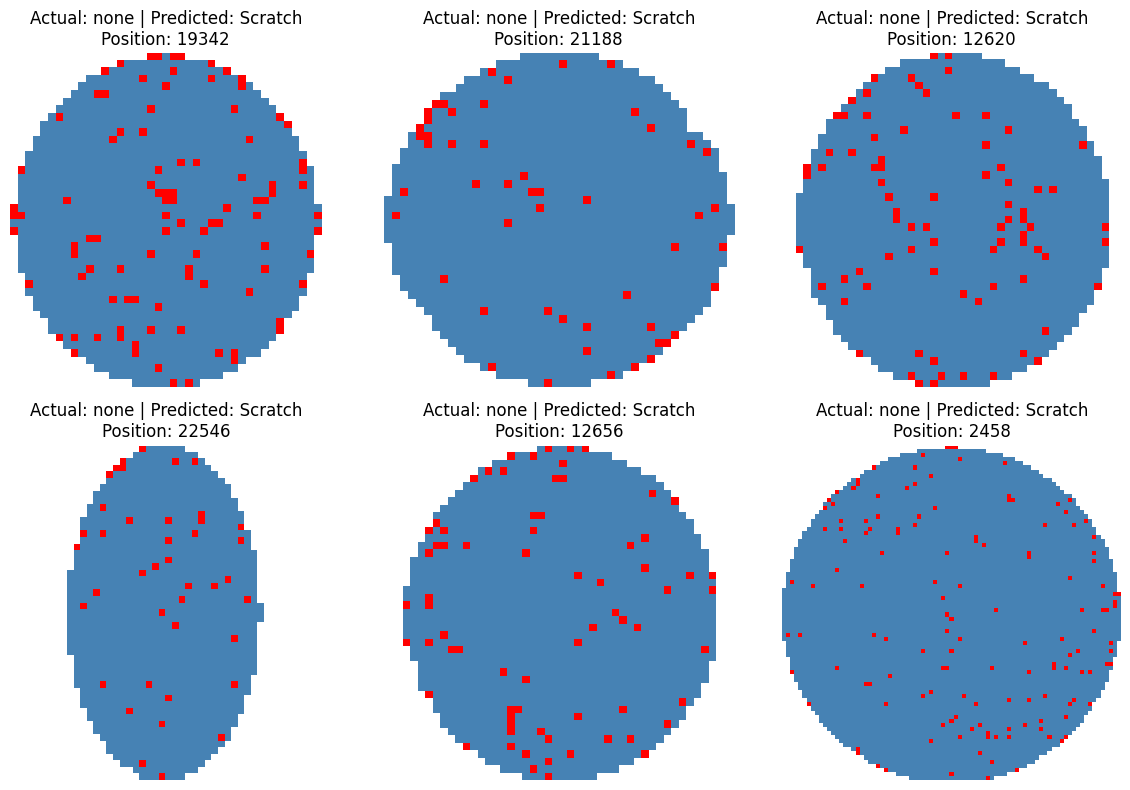

In [60]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Find positions where the actual class is none,
# but the model predicted Scratch.
wrong_positions = np.flatnonzero(
    (true_labels == class_to_idx["none"])
    & (predicted_labels == class_to_idx["Scratch"])
)

# Randomly choose up to six examples, reproducibly.
rng = np.random.default_rng(42)
selected_positions = rng.choice(
    wrong_positions,
    size=min(6, len(wrong_positions)),
    replace=False
)

wafer_colors = ListedColormap(["white", "steelblue", "red"])

fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for ax in axes.flat:
    ax.axis("off")

for ax, position in zip(axes.flat, selected_positions):
    # Validation predictions follow this order because shuffle=False.
    row = val_dataset.records.iloc[int(position)]

    ax.imshow(
        row["waferMap"],
        cmap=wafer_colors,
        vmin=0,
        vmax=2,
        interpolation="nearest"
    )
    ax.set_title(f"Actual: none | Predicted: Scratch\nPosition: {position}")

plt.tight_layout()
plt.show()

In [61]:
assert torch.cuda.is_available(), "GPU is unavailable; wait before training."
device = torch.device("cuda")

# Restore the same starting model used for our previous experiment.
starting_checkpoint = torch.load(
    head_checkpoint_path,
    map_location="cpu",
    weights_only=True
)

assert starting_checkpoint["class_to_idx"] == class_to_idx

model.load_state_dict(starting_checkpoint["model_state_dict"])
model = model.to(device)

# Restore the training shuffle state for a comparable batch order.
train_generator.set_state(
    starting_checkpoint["train_generator_state"]
)
assert train_loader.generator is train_generator

del starting_checkpoint

# Train only layer4 and the final classifier, as before.
for parameter in model.parameters():
    parameter.requires_grad = False

for parameter in model.layer4.parameters():
    parameter.requires_grad = True

for parameter in model.fc.parameters():
    parameter.requires_grad = True

# Calculate gentler weights using training data only.
class_order = sorted(class_to_idx, key=class_to_idx.get)

class_counts = (
    train_clean["label"]
    .value_counts()
    .reindex(class_order)
)

inverse_weights = len(train_clean) / (
    len(class_order) * class_counts
)
sqrt_weights = np.sqrt(inverse_weights)

criterion = nn.CrossEntropyLoss(
    weight=torch.tensor(
        sqrt_weights.to_numpy(),
        dtype=torch.float32,
        device=device
    )
)

# Use the same learning rates and a fresh optimizer.
optimizer = torch.optim.Adam([
    {"params": model.layer4.parameters(), "lr": 0.00001},
    {"params": model.fc.parameters(), "lr": 0.0001}
])

print(pd.DataFrame({
    "original_weight": inverse_weights,
    "new_weight": sqrt_weights
}))

           original_weight  new_weight
label                                 
Center            4.424205    2.103380
Donut            36.300243    6.024968
Edge-Loc          3.680302    1.918411
Edge-Ring         1.935308    1.391153
Loc               5.531178    2.351846
Near-full       130.253813   11.412879
Random           21.851791    4.674590
Scratch          15.323978    3.914585
none              0.130574    0.361350


In [62]:
sqrt_history, sqrt_folder = fit_classifier(
    epochs=2,
    stage="layer4_sqrt_weights",
    parent_checkpoint=str(head_checkpoint_path)
)

Checkpoints will be saved in: /content/drive/MyDrive/wafer_defect_project/Checkpoints/layer4_sqrt_weights_20261007_004817_198425

Epoch 1/2: training...
Checking the full validation set...
Training loss: 0.6424 | Validation loss: 0.5848 | Validation macro F1: 0.6546
Checkpoint saved.

Epoch 2/2: training...
Checking the full validation set...
Training loss: 0.5056 | Validation loss: 0.5459 | Validation macro F1: 0.6656
Checkpoint saved.


In [63]:
# Load the checkpoint with the highest validation macro F1.
selected_checkpoint_path = sqrt_folder / "best.pth"

selected_checkpoint = torch.load(
    selected_checkpoint_path,
    map_location="cpu",
    weights_only=True
)

assert selected_checkpoint["class_to_idx"] == class_to_idx

model.load_state_dict(selected_checkpoint["model_state_dict"])
model = model.to(device)
model.eval()

print("Selected epoch:", selected_checkpoint["completed_epochs"])
print("Validation macro F1:", selected_checkpoint["best_macro_f1"])

del selected_checkpoint

# Generate predictions for the full validation set.
val_true = []
val_pred = []

with torch.no_grad():
    for images, labels in val_loader:
        outputs = model(images.to(device))
        predictions = outputs.argmax(dim=1)

        val_true.extend(labels.cpu().tolist())
        val_pred.extend(predictions.cpu().tolist())

class_order = sorted(class_to_idx, key=class_to_idx.get)

print(classification_report(
    val_true,
    val_pred,
    labels=list(range(len(class_order))),
    target_names=class_order,
    digits=4,
    zero_division=0
))

Selected epoch: 2
Validation macro F1: 0.6655981390799478
              precision    recall  f1-score   support

      Center     0.8107    0.8023    0.8065       683
       Donut     0.4450    0.9151    0.5988       106
    Edge-Loc     0.5670    0.4437    0.4978       782
   Edge-Ring     0.9436    0.9608    0.9521      1376
         Loc     0.4875    0.1931    0.2766       606
   Near-full     0.6410    0.9615    0.7692        26
      Random     0.8372    0.8926    0.8640       121
     Scratch     0.1916    0.3793    0.2546       145
        none     0.9655    0.9761    0.9707     22104

    accuracy                         0.9324     25949
   macro avg     0.6543    0.7249    0.6656     25949
weighted avg     0.9297    0.9324    0.9287     25949



In [64]:
# Keep evaluation files together for this experiment.
evaluation_folder = results_folder / sqrt_folder.name
evaluation_folder.mkdir(parents=True, exist_ok=True)

assert selected_checkpoint_path == sqrt_folder / "best.pth"

validation_report = classification_report(
    val_true,
    val_pred,
    labels=list(range(len(class_order))),
    target_names=class_order,
    output_dict=True,
    zero_division=0
)

selection_record = {
    "checkpoint_path": str(selected_checkpoint_path),
    "selection_metric": "validation_macro_f1",
    "weighting": "square_root_inverse_frequency",
    "validation_report": validation_report
}

with open(evaluation_folder / "model_selection.json", "w") as file:
    json.dump(selection_record, file, indent=2)

print("Model selection saved.")

Model selection saved.


In [65]:
model.eval()

test_true = []
test_pred = []

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images.to(device))
        predictions = outputs.argmax(dim=1)

        test_true.extend(labels.cpu().tolist())
        test_pred.extend(predictions.cpu().tolist())

assert len(test_true) == len(test_dataset)

print(classification_report(
    test_true,
    test_pred,
    labels=list(range(len(class_order))),
    target_names=class_order,
    digits=4,
    zero_division=0
))

# Save predictions so we can analyze them without rerunning inference.
pd.DataFrame({
    "true_class_id": test_true,
    "predicted_class_id": test_pred
}).to_csv(
    evaluation_folder / "test_predictions.csv",
    index=False
)

test_report = classification_report(
    test_true,
    test_pred,
    labels=list(range(len(class_order))),
    target_names=class_order,
    output_dict=True,
    zero_division=0
)

with open(evaluation_folder / "test_report.json", "w") as file:
    json.dump(test_report, file, indent=2)

              precision    recall  f1-score   support

      Center     0.7529    0.7492    0.7510       602
       Donut     0.3950    0.9518    0.5583        83
    Edge-Loc     0.5968    0.4352    0.5034       772
   Edge-Ring     0.9651    0.9665    0.9658      1432
         Loc     0.5060    0.2209    0.3075       575
   Near-full     0.5185    0.9333    0.6667        15
      Random     0.8647    0.8779    0.8712       131
     Scratch     0.2628    0.4633    0.3354       177
        none     0.9647    0.9764    0.9705     22066

    accuracy                         0.9335     25853
   macro avg     0.6474    0.7305    0.6589     25853
weighted avg     0.9312    0.9335    0.9301     25853

